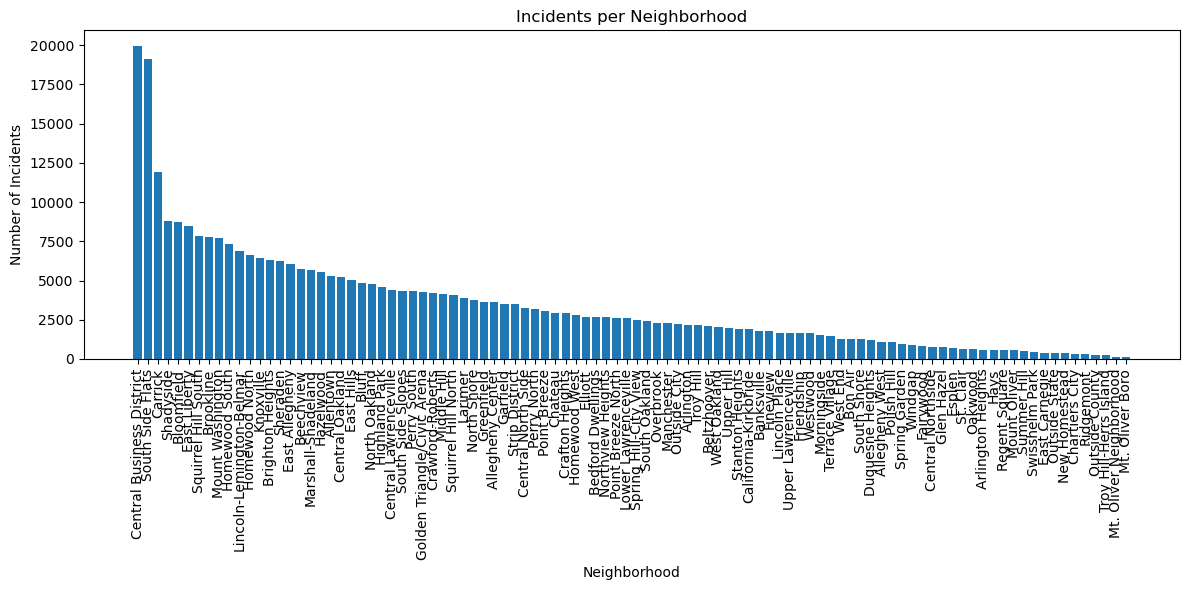

In [5]:
incident_counts = incidents.groupby("INCIDENTNEIGHBORHOOD").size().reset_index(name="incident_count")
incident_counts = incident_counts.sort_values(by="incident_count", ascending=False)
plt.figure(figsize=(12,6))
plt.bar(incident_counts["INCIDENTNEIGHBORHOOD"], incident_counts["incident_count"])
plt.xticks(rotation=90)
plt.xlabel("Neighborhood")
plt.ylabel("Number of Incidents")
plt.title("Incidents per Neighborhood")
plt.tight_layout()
plt.show()

Hard to read, so lets see the top 20 safest:

In [6]:
top20_safest = incident_counts.sort_values(by="incident_count", ascending=True).head(20)
top20_safest

,INCIDENTNEIGHBORHOOD,incident_count
56,Mt. Oliver Boro,101
57,Mt. Oliver Neighborhood,117
91,Troy Hill-Herrs Island,252
64,Outside County,256
73,Ridgemont,296
21,Chartiers City,339
58,New Homestead,353
27,East Carnegie,401
65,Outside State,401
88,Swisshelm Park,443


Not extremely helpful overall though because a neighborhood with fewer people would probably have fewer incidents happen. So lets see compared to the relative amount of people in the neighborhood.

In [7]:
populationNH = pd.read_csv("https://data.wprdc.org/dataset/5b18c198-474c-4723-b735-cc5220ad43cc/resource/82f29015-6905-4b1c-8300-afe9bb2231b3/download/total-population.csv"
                           )
populationNH.head(20)

,Neighborhood,Id,Estimate; Total,Margin of Error; Total
0,Allegheny Center,1,1411.0,196.000000
1,Allegheny West,2,343.0,96.000000
2,Allentown,3,2558.0,449.773276
3,Arlington,4,1852.0,348.188168
4,Arlington Heights,5,272.0,126.000000
5,Banksville,6,3858.0,581.107563
6,Bedford Dwellings,7,1349.0,180.000000
7,Beechview,8,8078.0,719.658252
8,Beltzhoover,9,1702.0,343.072879
9,Bloomfield,10,8669.0,491.348145


In [31]:
incidents = incidents.rename(columns={"INCIDENTNEIGHBORHOOD": "neighborhood"})
populationNH = populationNH.rename(columns={"Neighborhood": "neighborhood", "Estimate; Total": "population"})
incident_counts = incidents.groupby("neighborhood").size().reset_index(name="incident_count")
incident_rates = incident_counts.merge(populationNH, on="neighborhood", how="inner")

In [32]:
incident_rates["incidents_per_1000"] = (incident_rates["incident_count"] / incident_rates["population"]) * 1000
print(incident_rates)

           neighborhood  incident_count  Id  population  \
0      Allegheny Center            3614   1      1411.0   
1        Allegheny West            1094   2       343.0   
2             Allentown            5273   3      2558.0   
3             Arlington            2166   4      1852.0   
4     Arlington Heights             573   5       272.0   
..                  ...             ...  ..         ...   
84  Upper Lawrenceville            1670  87      2754.0   
85             West End            1290  88       235.0   
86         West Oakland            2014  89      1717.0   
87             Westwood            1650  90      3537.0   
88              Windgap             886  91      1534.0   

    Margin of Error; Total  incidents_per_1000  
0               196.000000         2561.304040  
1                96.000000         3189.504373  
2               449.773276         2061.376075  
3               348.188168         1169.546436  
4               126.000000         2106.617647

Awesome, Now lets go back to a bar graph for a visual.

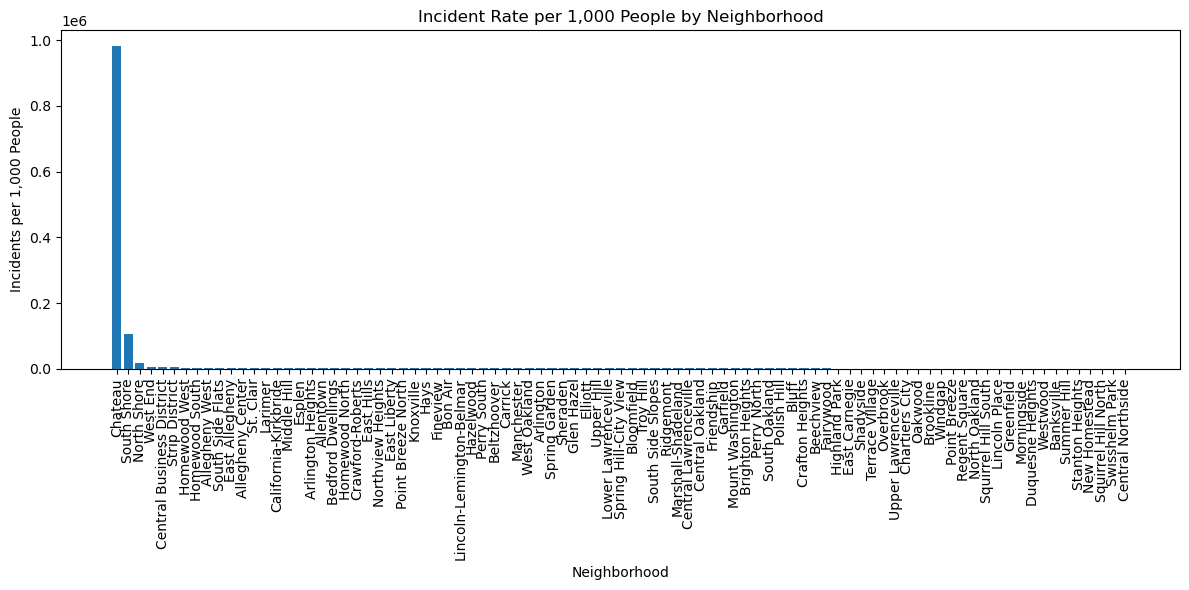

In [38]:
incident_rates = incident_rates.sort_values(by="incidents_per_1000", ascending=False)
plt.figure(figsize=(12,6))
plt.bar(incident_rates["neighborhood"], incident_rates["incidents_per_1000"])
plt.xticks(rotation=90)
plt.xlabel("Neighborhood")
plt.ylabel("Incidents per 1,000 People")
plt.title("Incident Rate per 1,000 People by Neighborhood")
plt.tight_layout()
plt.show()

In [39]:
safest_20 = (incident_rates.sort_values(by="incidents_per_1000", ascending=True).head(20)["neighborhood"])
print(safest_20.to_string(index=False))

  Central Northside
     Swisshelm Park
Squirrel Hill North
      New Homestead
    Stanton Heights
        Summer Hill
         Banksville
           Westwood
   Duquesne Heights
        Morningside
         Greenfield
      Lincoln Place
Squirrel Hill South
      North Oakland
      Regent Square
       Point Breeze
            Windgap
          Brookline
            Oakwood
     Chartiers City


Conclusion:
I was honestly quite surprised with the selection of neighborhoods I got here. Looking at the bar graph, you could clearly tell most of the neighborhoods relative to each other were pretty similar in incident rate, so I felt the top 20 were all about equally viable options as far as safety, especially once you add in the other factors from my groupmates. Another important part was adding in the population dataset to get an actual relative idea of how safe an area was. If I hadn't added this part, then we would have had a very different list, which you can tell looking at the graph before population was factored in. I don't have much of a personal favorite neighborhood since I'm not from here but I do like most of these options from the ones I've been to.